# 01 · Exploratory Data Analysis

Data loading, cleaning, and EDA for the Shopper Spectrum project. Uses the project package directly.

## Setup, load & clean

In [1]:
import sys; sys.path.insert(0, '../src')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from shopper_spectrum.config import load_config
from shopper_spectrum.data.loader import load_raw
from shopper_spectrum.data.preprocessing import clean
cfg = load_config('../config/config.yaml')
df = clean(load_raw('../data/raw/online_retail.csv'), cfg['preprocessing'])
print('Clean rows:', len(df), '| Customers:', df['CustomerID'].nunique())
df.head()

Clean rows: 392688 | Customers: 4338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Missing values & data quality

In [2]:
raw = load_raw('../data/raw/online_retail.csv')
print('Missing values:'); print(raw.isnull().sum())
print('\nCancelled:', raw['InvoiceNo'].astype(str).str.startswith('C').sum())
print('Non-positive qty:', (raw['Quantity']<=0).sum(), '| Non-positive price:', (raw['UnitPrice']<=0).sum())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Cancelled: 9288
Non-positive qty: 10624 | Non-positive price: 2517


## Transaction volume by country

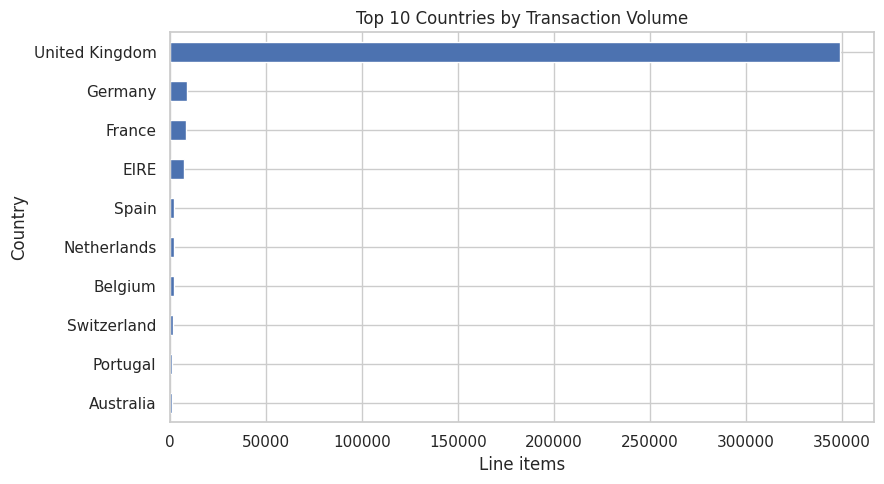

In [3]:
df['Country'].value_counts().head(10).iloc[::-1].plot(kind='barh', figsize=(9,5), color='#4C72B0')
plt.title('Top 10 Countries by Transaction Volume'); plt.xlabel('Line items'); plt.tight_layout(); plt.show()

## Top-selling products

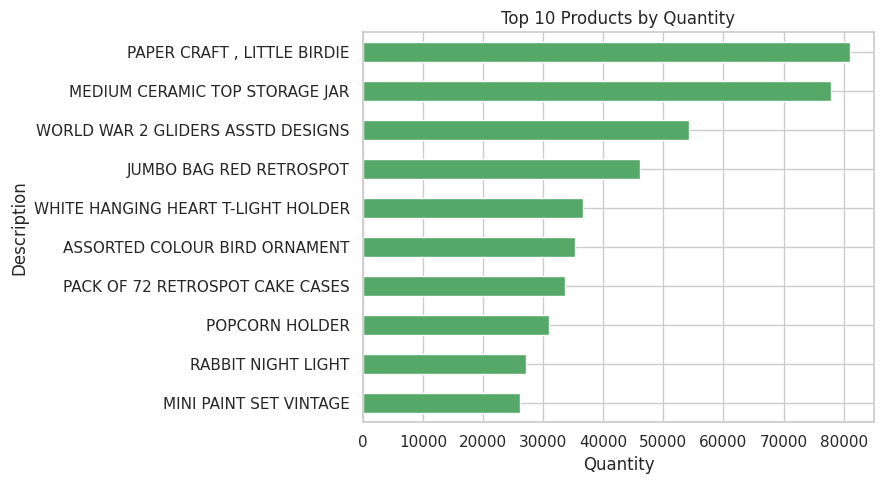

In [4]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).iloc[::-1].plot(kind='barh', figsize=(9,5), color='#55A868')
plt.title('Top 10 Products by Quantity'); plt.xlabel('Quantity'); plt.tight_layout(); plt.show()

## Revenue trend over time

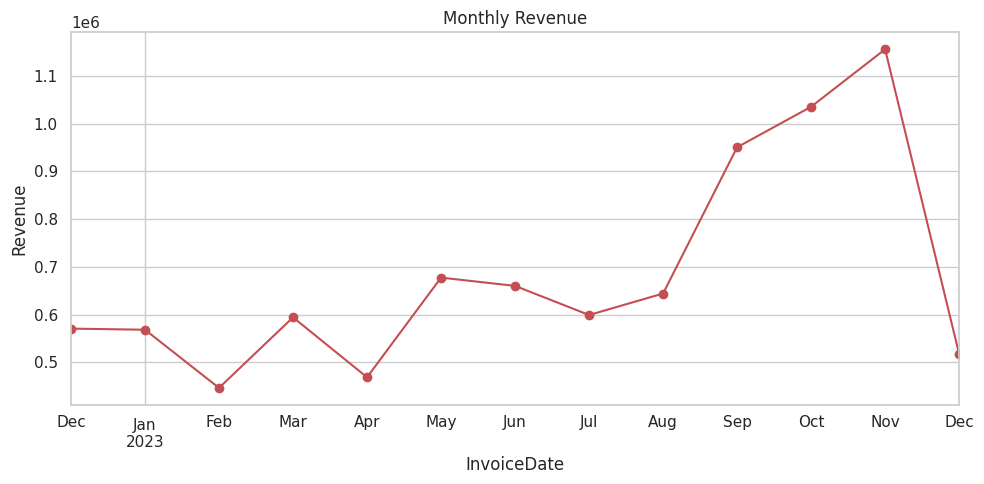

In [5]:
df.set_index('InvoiceDate')['TotalPrice'].resample('ME').sum().plot(marker='o', figsize=(10,5), color='#C44E52')
plt.title('Monthly Revenue'); plt.ylabel('Revenue'); plt.tight_layout(); plt.show()

## Monetary distribution: per transaction and per customer

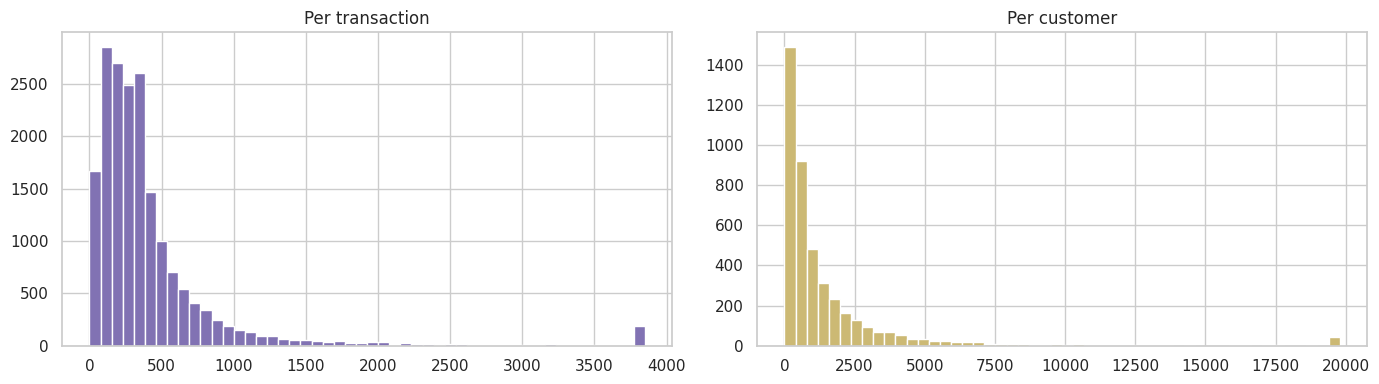

In [6]:
fig, ax = plt.subplots(1,2,figsize=(14,4))
inv = df.groupby('InvoiceNo')['TotalPrice'].sum()
ax[0].hist(inv.clip(upper=inv.quantile(0.99)), bins=50, color='#8172B3'); ax[0].set_title('Per transaction')
cust = df.groupby('CustomerID')['TotalPrice'].sum()
ax[1].hist(cust.clip(upper=cust.quantile(0.99)), bins=50, color='#CCB974'); ax[1].set_title('Per customer')
plt.tight_layout(); plt.show()